# Domácí úkol č. 2 - 🕸 Síťová analýza PID

## 📚 Data
Jako dataset nám poslouží [otevřená data Pražské integrované dopravy](https://pid.cz/o-systemu/opendata/). Konkrétně budeme pracovat s daty [cestovních řádů](https://pid.cz/o-systemu/opendata/#h-gtfs), která jsou původně ve formátu GTFS (General Transit Feed Specification). To je formát, který využívá široká škála softwarových aplikací a kvůli tomu jej při publikaci dat využívají také veřejné dopravní agentury včetně PID.

☝️**Pozor!** Pro řešení domácí úlohy vám poskytneme už připravený dataset $D$ ve formátu `csv`. Dataset $D$ jsme pro vás sestavili z dat, která pocházejí z [cestovních řádů](https://pid.cz/o-systemu/opendata/#h-gtfs). Více informací o všech souborech a jejich atributech lze nalézt v [dokumentaci formátu GTFS](https://developers.google.com/transit/gtfs/reference).

## Zadání
> ☝️ Používejte markdown buňky! Zdůvodňujte všechny důležité kroky, popisujte vizualizace a co je z nich možné pozorovat. Za nepřehledný domácí úkol nebudou uděleny body.

Za řádné průběžné komentování a vizuální prezentaci postupu a výsledků lze získat až 4 body. Úkol řešíte jako **jednotlivci**.

**✨ Dataset**
* Načtěte si data ze souboru `d.csv`, což je již zmíněný dataset $D$, který obsahuje záznam pro každé dvě **po sobě jdoucí** zastávky nějakého spoje.
* Struktura je následující (pro zjednodušení neuvažujeme service start_date a end_date):
| stop_from | stop_from_name | stop_to | stop_to_name | depart_from | arrive_to | route_type | is_night | mon | tue | wed | thu | fri | sat | sun |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| U699Z3P | Stadion Strahov | U981Z1P | Koleje Strahov | 7:24:00 | 7:25:00 | 3 | 0 | 1 | 1 | 1 | 1 | 1 | 0 | 0 |

* Za jedinečný identifikátor zastávky můžete považovat **název zastávky**. Pozor na stejné názvy zastávek pro různé dopravní prostředky - u takových zastávek můžete uvažovat, že se jedná o jednu a tutéž stanici (v mnoha případech to i platí). 

**⚙️ Předzpracování dat**

* Atributy `depart_from` a `arrive_to` budete chtít nejspíše upravit. Obsahují totiž časové údaje delší než 24 hodin (celkem se jedná o 1.5 % záznamů). Z reference formátu GTFS (info o sloupci, z kterého vznikl `depart_from` a `arive_to`): _Arrival time at a specific stop for a specific trip on a route. … For times occurring after midnight on the service day, enter the time as a value greater than 24:00:00 in HH:MM:SS local time for the day on which the trip schedule begins._ Nicméně narazíte i na chybné časy, které začínají s hodnotou větší než 24. Všechny tyto případy můžete vyřešit pomocí **modulo 24** ☝️.


**🕸️ Základní síťová analýza** (celkem 12 bodů)

Úkolem je analyzovat síť zastávek PID. Zastávky tedy budou uzly sítě. Mezi dvěma zastávkami je orientovaná hrana, pokud jsou to dvě po sobě jdoucí zastávky nějakého spoje (existuje alespoň jeden záznam v datasetu $D$ s odpovídajícími `stop_from`, `stop_to`). Váha hrany je rovna počtu dopravních prostředků, které na dané trase za období jednoho týdne projedou.

Postupujte následovně:
* Začněte volbou libovolného balíčku pro analýzu a vizualizaci sítí (lze využít i zmíněný NetworkX),
* z datasetu $D$ vytvořte reprezentaci dat, která je vhodná pro vámi zvolený vizualizační balíček,
* vytvořte vizualizaci sítě (celkem za 4 body) - vizualizace musí být čitelná, proto můžete vizualizovat i podčást sítě (např. pro určitý dopravní prostředek, např. tramvaje (kromě vizualizace sítě lanovky nebo metra, tu neuznáváme) nebo nějaký podgraf - řešení ponecháme na vás),
* pomocí alespoň tří měr centrality analyzujte důležitost zastávek za období jednoho týdne (pondělí - neděle) a komentujte slovně, co tyto míry vzhledem ke konkrétním datům znamenají (každá míra za 2 body, celkem tedy za 6 bodů),
* vytvořte vizualizaci pro alespoň jednu míru centrality (celkem za 2 body) nad sítí. 

**❓ Vlastní otázky** (3 body za každou otázku, celkem max. 9 bodů)

Vytvořte 3 otázky (můžete i více), založené na filtraci datasetu $D$ a odpovídejte na ně vhodnými vizualizacemi. Otázky pro inspiraci:
* Mění se důležité zastávky v závislosti na denním/nočním provozu?
* Je rozdíl ve vytíženosti zastávek během pracovního týdne/víkendu?
* ...

**🔥 Data navíc**

V souboru `stops.txt` je u každé zastávky uvedena **zeměpisná šířka a délka**. Tato data můžete využít pro rozšíření své analýzy a také vám mohou pomoci při layoutování grafu. ☝️ Pozor na stejné názvy zastávek s trochu jinou lokací pro různé dopravní prostředky. Je třeba navrhnout nějaké řešení (např. první, průměr, těžiště mnohoúhelníku apod., libovolně dle vašeho úsudku) a to zdůvodnit.

| stop_id | stop_name | stop_lat | stop_lon | zone_id | stop_url | location_type | parent_station | wheelchair_boarding | level_id | platform_code | asw_node_id | asw_stop_id |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| U699Z3P | Stadion Strahov | 50.078484 | 14.389113 | P | NaN | 0 | NaN | 0 | NaN | C | 699.0 | 3.0 |

### Bodové hodnocení
Shrnutí bodů, které můžete nejvýše získat:
- 4 body za průběžné komentáře a vizuální prezentaci postupu a výsledků,
- 4 body za vizualizaci sítě,
- 6 bodů za komentovanou analýzu alespoň 3 měr centrality,
- 2 body za vizualizaci jedné z měr centrality (nad sítí, ne pouze sloupcový graf!),
- 9 bodů za definici a zodpovězení minimálně tří vlastních otázek.

Celkem lze za domácí úkol č. 2 získat maximálně 25 bodů.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
timetables = pd.read_csv('d.csv')
stops = pd.read_csv('stops.txt')

### Popis dat

In [3]:
display(timetables.sample(2))
stops.sample(2)

,stop_from,stop_from_name,stop_to,stop_to_name,depart_from,arrive_to,route_type,is_night,monday,tuesday,wednesday,thursday,friday,saturday,sunday
536998,U160Z1P,Hostivařské náměstí,U641Z1P,Selská,12:03:00,12:05:00,3,0,0,0,0,0,0,1,1
437819,U731Z2P,V Ladech,U730Z2P,Šeberov,17:18:00,17:19:00,3,0,1,1,1,1,1,0,0


,stop_id,stop_name,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,wheelchair_boarding,level_id,platform_code,asw_node_id,asw_stop_id
5632,U2163Z1,"Úžice,Čekanov,Pražská",49.889328,14.956094,5,NaN,0,NaN,2,NaN,A,2163.0,1.0
2715,U821Z1P,Náměstí Winstona Churchilla,50.084133,14.440366,P,NaN,0,NaN,0,NaN,A,821.0,1.0


In [4]:
timetables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1642433 entries, 0 to 1642432
Data columns (total 15 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   stop_from       1642433 non-null  object
 1   stop_from_name  1642433 non-null  object
 2   stop_to         1642433 non-null  object
 3   stop_to_name    1642433 non-null  object
 4   depart_from     1642433 non-null  object
 5   arrive_to       1642433 non-null  object
 6   route_type      1642433 non-null  int64 
 7   is_night        1642433 non-null  int64 
 8   monday          1642433 non-null  int64 
 9   tuesday         1642433 non-null  int64 
 10  wednesday       1642433 non-null  int64 
 11  thursday        1642433 non-null  int64 
 12  friday          1642433 non-null  int64 
 13  saturday        1642433 non-null  int64 
 14  sunday          1642433 non-null  int64 
dtypes: int64(9), object(6)
memory usage: 188.0+ MB


Timetables obsahuje 1 642 433 záznamů a žádné chybějící hodnoty.

Příznaky v tabulce:
  - **stop_from / stop_to**
    - kód zastávky
  - **stop_from_name / stop_to_name**
    - název zastávky
  - **depart_from / arrive_to**
    - čas odjezdu / příjezdu
    - některé hodnoty jsou špatně
  - **route_type**
    - typ dopravního prostředku:
      - 0 - tramvaj
      - 1 – metro
      - 2 – vlak
      - 3 – autobus
      - 4 – přívoz (loď)
      - 7 – lanovka
  - **is_night**
    - zda se jedná o noční spoj
    - čas je mezi 22:00 a 06:00
  - **monday / tuesday / wednesday / thursday / friday / saturday / sunday**
    - dny v týdnu, ve kterých spoj jezdí

In [5]:
stops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16435 entries, 0 to 16434
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              16435 non-null  object 
 1   stop_name            15936 non-null  object 
 2   stop_lat             16435 non-null  float64
 3   stop_lon             16435 non-null  float64
 4   zone_id              15408 non-null  object 
 5   stop_url             0 non-null      float64
 6   location_type        16435 non-null  int64  
 7   parent_station       954 non-null    object 
 8   wheelchair_boarding  16435 non-null  int64  
 9   level_id             954 non-null    object 
 10  platform_code        14750 non-null  object 
 11  asw_node_id          15748 non-null  float64
 12  asw_stop_id          15354 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


Stops obsahuje 16 435 záznamů ale některé přiznaky mají chybějící hodnoty.

Příznaky v tabulce:
  - **stop_id**
    - kód zastávky
  - **stop_name**
    - název zastávky
  - **stop_lat / stop_lon**
    - zeměpisná šířka a délka
  - **zone_id**
    - pásmové zařazení zastávky
    - může obsahovat i více hodnot nebo být prázdny
  - **stop_url**
    - prázdny sloupec
  - **location_type**
    - typ lokace, musi mit predurčenou hodnotu
      - 0 - zastávky (autobusy, tramvaje)
      - 1 - stanice (metro)
      - 2 - vstup / výstup
      - 3 - ostatní
  - **parent_station**
    - určuje hierarchii mezi jednotlivými typy míst
    - přiřazuje příslušnou nadřazenou stanici podle jeho typu
  - **wheelchair_boarding**
    - jestli je možný nástup na vozíku
      - 0 - žadné informace o stavu
      - 1 - dá se nastupovat s vozíkem
      - 2 - nedá se nastupovat s vozíkem
  - **level_id**
    - určuje úroveň (podlaží) ve stanici
  - **platform_code**
    - kód stanoviště
    - pod jedním jménem zastávky může bít více stanovišť
  - **asw_node_id / asw_stop_id**
    - dohromady tvoří identifikátor zastávky
   

### Úprava dat

Dataset je velmi veliký a obsahuje různé druhy spojů. Vytvořit čistou a čitelnou reprezentaci celé sítě by bylo velmi obtížné, nebo bych mohl zobrazovat pouze malé úseky. Proto se zaměříme pouze na tramvajové zastávky a spoje.

Kromě chybných hodnot v časových údajích jsem v záznamech nenašel žádné další chyby.

In [6]:
def correct_time (df, col):
    time_parts = df[col].str.split(':', expand=True)

    time_parts[0] = time_parts[0].astype(int) % 24
    time_parts[0] = time_parts[0].astype(str).str.zfill(2)
    df[col] = time_parts[0] + ':' + time_parts[1]

    return df

timetables = correct_time(timetables, 'depart_from')
timetables = correct_time(timetables, 'arrive_to')

In [7]:
tram_timetables = timetables[timetables['route_type'] == 0].copy()

### Tvorba grafu

V grafu budou uzly reprezentovat zastávky a hrany spoje mezi nimi. Tloušťka hran odpovídá počtu spojů, které mezi zastávkami projedou během týdne.

Pro polohu uzlů použijeme jejich skutečnou geografickou šířku a délku. Protože analyzujeme zatížení zastávek, jejich reálné rozmístění v prostoru nám může pomoci lépe pochopit, proč jsou některé zastávky více vytížené, než kdybychom je uměle rozmísťovali.

V datasetu se může stát, že pro jednu zastávku existuje více záznamů s různými souřadnicemi. Tyto záznamy spojíme pomocí průměrné hodnoty souřadnic. Kvůli tomu se může stát, že některé zastávky budou na vizualizaci mírně posunuté oproti své skutečné poloze.

In [8]:
tram_timetables['weekly_trips'] = (
    tram_timetables['monday'] + tram_timetables['tuesday'] + tram_timetables['wednesday'] +
    tram_timetables['thursday'] + tram_timetables['friday'] + tram_timetables['saturday'] +
    tram_timetables['sunday']
)

edges_df = tram_timetables.groupby(['stop_from_name', 'stop_to_name'])['weekly_trips'].sum().reset_index()

In [9]:
stops_grouped = stops.groupby('stop_name')[['stop_lon', 'stop_lat']].mean().reset_index()

all_stops = set(edges_df['stop_from_name']).union(set(edges_df['stop_to_name']))
pos_dict  = {row['stop_name']: (row['stop_lon'], row['stop_lat']) for _, row in stops_grouped.iterrows() if row['stop_name'] in all_stops}

In [10]:
print(f"Počet zastávek (uzlů): {len(all_stops)}")
print(f"Počet jizd (hran):    {len(edges_df)}")

Počet zastávek (uzlů): 281
Počet jizd (hran):    661


In [11]:
G = nx.DiGraph()

G.add_nodes_from(all_stops)

for _, row in edges_df.iterrows():
    G.add_edge(row['stop_from_name'], row['stop_to_name'], weight=row['weekly_trips'])

print(G)

DiGraph with 281 nodes and 661 edges


### Vizualizace sítě

Nejdříve se podíváme na celou tramvajovou síť spojení a pak, podrobněji, na nějakou část, ve které se vyskytují zajímavé uzly a hrany. Nejspíše to bude centrum.

Používáme skutečnou polohu zastávek, proto pro lepší orientaci do grafu přidáme i stanice metra a Vltavu, také podle jejich skutečných poloh.

Teď se budeme soustředit na hrany, počet průchodů tramvají z jedné zastávky do jiné. Zastávky budou reprezentovány jednoduše bodem. Na zastávky se podívame později.

In [12]:
line_A_stations = ['Nemocnice Motol', 'Petřiny', 'Nádraží Veleslavín', 'Bořislavka', 'Dejvická', 'Hradčanská', 'Malostranská', 'Staroměstská',
                   'Můstek', 'Muzeum', 'Náměstí Míru', 'Jiřího z Poděbrad', 'Flora', 'Želivského', 'Strašnická', 'Skalka', 'Depo Hostivař']

line_B_stations = ['Zličín', 'Stodůlky', 'Luka', 'Lužiny', 'Hůrka', 'Nové Butovice', 'Radlická', 'Smíchovské nádraží', 'Anděl', 'Karlovo náměstí',
                   'Národní třída', 'Můstek', 'Náměstí Republiky', 'Florenc', 'Křižíkova', 'Invalidovna', 'Palmovka', 'Českomoravská', 'Vysočanská',
                   'Kolbenova', 'Hloubětín', 'Rajská zahrada', 'Černý Most']

line_C_stations = ['Háje', 'Opatov', 'Chodov', 'Roztyly', 'Kačerov', 'Budějovická', 'Pankrác', 'Pražského povstání', 'Vyšehrad', 'I.P.Pavlova',
                   'Muzeum', 'Hlavní nádraží', 'Florenc', 'Vltavská', 'Nádraží Holešovice', 'Kobylisy', 'Ládví', 'Střížkov', 'Prosek', 'Letňany']

def get_ordered_metro_stops (line):
    stops_line = stops_grouped[stops_grouped['stop_name'].isin(line)].copy()
    stops_line['stop_name'] = pd.Categorical(stops_line['stop_name'], categories=line, ordered=True)
    stops_line = stops_line.sort_values('stop_name').reset_index(drop=True)

    return stops_line

stops_A = get_ordered_metro_stops (line_A_stations)
stops_B = get_ordered_metro_stops (line_B_stations)
stops_C = get_ordered_metro_stops (line_C_stations)

In [13]:
vltava_lats = [49.995152, 49.998796, 50.004753, 50.010086, 50.015085, 50.020107, 50.024460,
               50.029359, 50.035127, 50.040605, 50.047158, 50.053437, 50.059026, 50.064900,
               50.070107, 50.075651, 50.079399, 50.084219, 50.088773, 50.092106, 50.093356,
               50.094122, 50.094680, 50.096676, 50.096299, 50.097556, 50.100963, 50.104816,
               50.108471, 50.111891, 50.113180, 50.113278, 50.112461, 50.111697, 50.113260,
               50.114292, 50.114048, 50.113676, 50.113731, 50.114805, 50.117613, 50.120152,
               50.122987, 50.125804, 50.128656, 50.131507, 50.133293, 50.135434]
              
vltava_lons = [14.401120, 14.402628, 14.401314, 14.397999, 14.396437, 14.395776, 14.396688,
               14.399706, 14.404228, 14.408236, 14.411536, 14.414186, 14.416126, 14.414470,
               14.412910, 14.411705, 14.411054, 14.410900, 14.412253, 14.415216, 14.418852,
               14.425933, 14.430045, 14.436148, 14.442835, 14.451186, 14.457697, 14.460251,
               14.459462, 14.455348, 14.448870, 14.442840, 14.436728, 14.429964, 14.421936,
               14.418173, 14.413714, 14.409994, 14.406153, 14.402179, 14.398335, 14.396579,
               14.396975, 14.399863, 14.401275, 14.398990, 14.395417, 14.392745]

In [14]:
custom_points = {
    'Anděl':                  (14.385,  50.077),
    'Kotlářka':               (14.362,  50.065),
    'Hlavní nádraží':         (14.470,  50.098),
    'Spojovací':              (14.505,  50.095),
    'Kubánské náměstí':       (14.455,  50.062),
    'Zahradní Město':         (14.505,  50.050),
    'Strossmayerovo náměstí': (14.390,  50.130),
    'Sparta':                 (14.400,  50.110),
    'Královský letohrádek' :  (14.360,  50.115),
    'Pražský hrad' :          (14.340,  50.110),
}

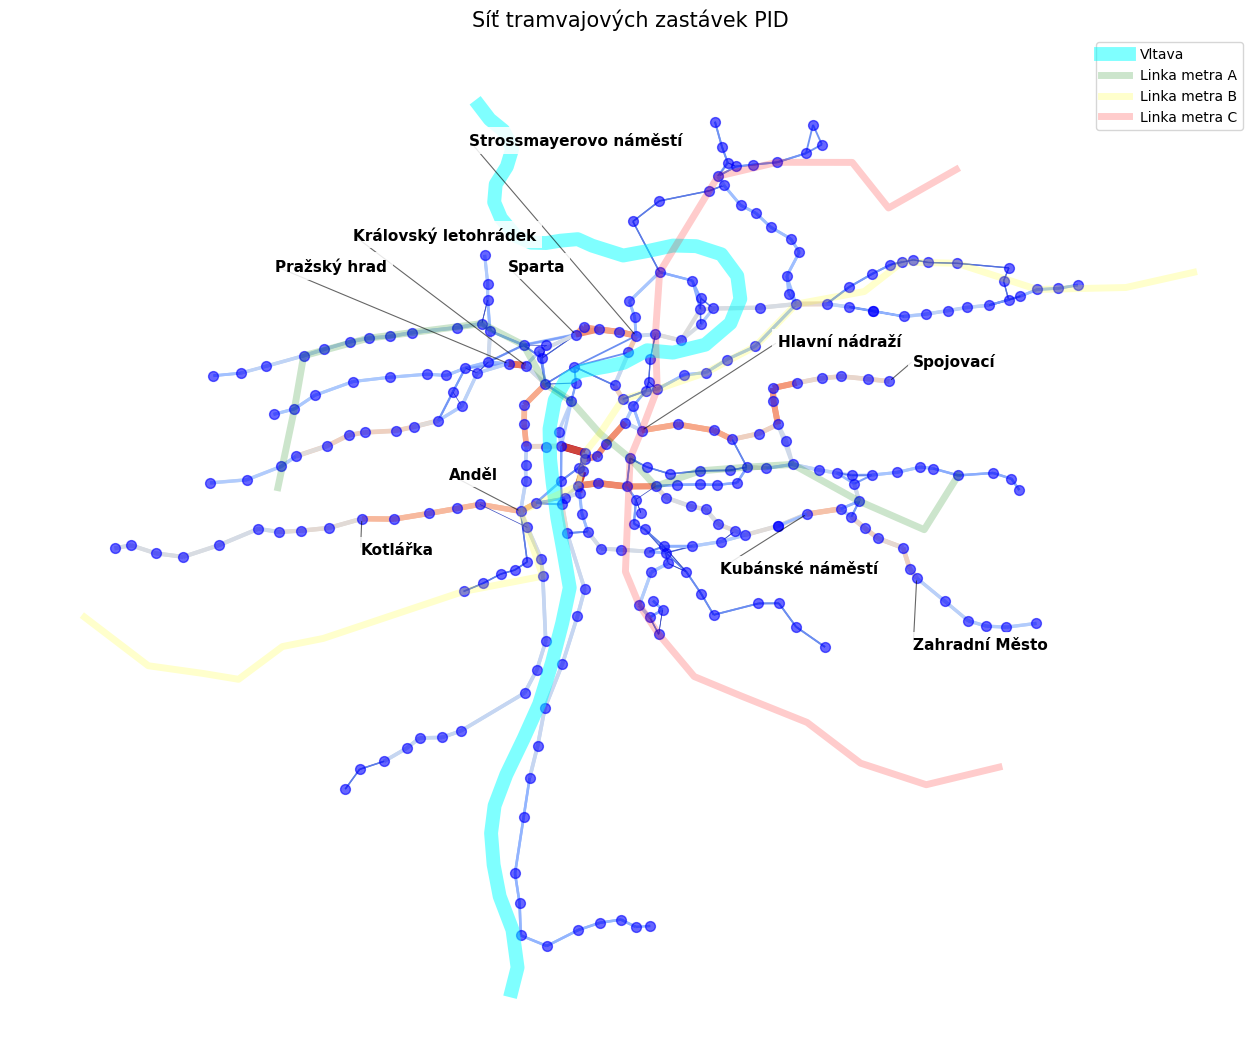

In [15]:
edge_weights = [data['weight'] for u, v, data in G.edges(data=True)]
max_edge_w   = max(edge_weights) if edge_weights else 1
norm_weights = [w / max_edge_w for w in edge_weights]
edge_widths  = [0.5 + 5 * (w / max_edge_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(16, 13))

nx.draw_networkx_nodes(G, pos=pos_dict, node_size=50, node_color='blue', alpha=0.6)
# zatím bez šipek pro čitelnos
nx.draw_networkx_edges(G, pos=pos_dict, width=edge_widths, alpha=1, edge_color=norm_weights, edge_cmap=plt.cm.coolwarm, arrows=False)

for station, (label_x, label_y) in custom_points.items():
    node_x, node_y = pos_dict[station]
    
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y),
                arrowprops=dict(arrowstyle='-', color='black', lw=0.8, alpha=0.6))
    
    ax.text(label_x, label_y, station,
            fontsize=11, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.5, label='Vltava')
ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

plt.title('Síť tramvajových zastávek PID', fontsize=15)
plt.axis('off')
plt.legend()
plt.show()

Jo, je to centrum. Na grafu vidíme spoje s největším počtem průchodů, čím je jich víc, tím je hrana tmavší a silnější. Máme ale i pár zajímavých spojů mimo centrum. Jsou to především spoje na sídlištích nebo na přestupních stanicích pro metro či jiné dopravní prostředky.

Na ty v centru se podíváme teď i trochu podrobněji.

In [16]:
custom_points = {
    'Anděl':                  (14.398,  50.071),
    'Hlavní nádraží':         (14.438,  50.087),
    'I. P. Pavlova' :         (14.425,  50.073),
    'Jindřišská' :            (14.425,  50.0865),
    'Kamenická':              (14.423,  50.098),
    'Karlovo náměstí' :       (14.422,  50.0717),
    'Královský letohrádek' :  (14.397,  50.0925),
    'Lazarská':               (14.4145, 50.079),
    'Letenské náměstí':       (14.418,  50.1015),
    'Malostranská':           (14.408,  50.088),
    'Moráň':                  (14.4155, 50.072),
    'Novoměstská radnice' :   (14.422,  50.0785),
    'Náměstí Míru':           (14.436,  50.072),
    'Národní divadlo' :       (14.405,  50.084),
    'Národní třída' :         (14.4165, 50.082),
    'Pražský hrad' :          (14.397,  50.0965),
    'Sparta':                 (14.416,  50.097),
    'Staroměstská':           (14.418,  50.089),
    'Strossmayerovo náměstí': (14.425,  50.103),
    'Václavské náměstí' :     (14.417,  50.085),
    'Vodičkova':              (14.426,  50.0805),
    'Štěpánská' :             (14.425,  50.077),
    'Újezd':                  (14.400,  50.081),
}

In [17]:
central_pos = {k: v for k, v in pos_dict.items() if 14.40 < v[0] < 14.455 and 50.065 < v[1] < 50.10}
central_G   = G.subgraph([n for n in G.nodes() if n in central_pos])

node_degrees = [d for n, d in central_G.degree(weight='weight')]
edge_weights = [data['weight'] for u, v, data in central_G.edges(data=True)]

max_deg    = max(node_degrees) if node_degrees else 1
max_edge_w = max(edge_weights) if edge_weights else 1

node_weights = [d / max_deg for d in node_degrees]
node_sizes   = [50 + 300 * (d / max_deg) for d in node_degrees]

edge_norm    = [w / max_edge_w for w in edge_weights]
edge_widths  = [0 + 5 * (w / max_edge_w) for w in edge_weights]

top_edges = sorted(list(central_G.edges(data=True)), key=lambda e: e[2].get('weight'), reverse=True)[:10]
top_edges_list = [(u, v) for u, v, _ in top_edges]

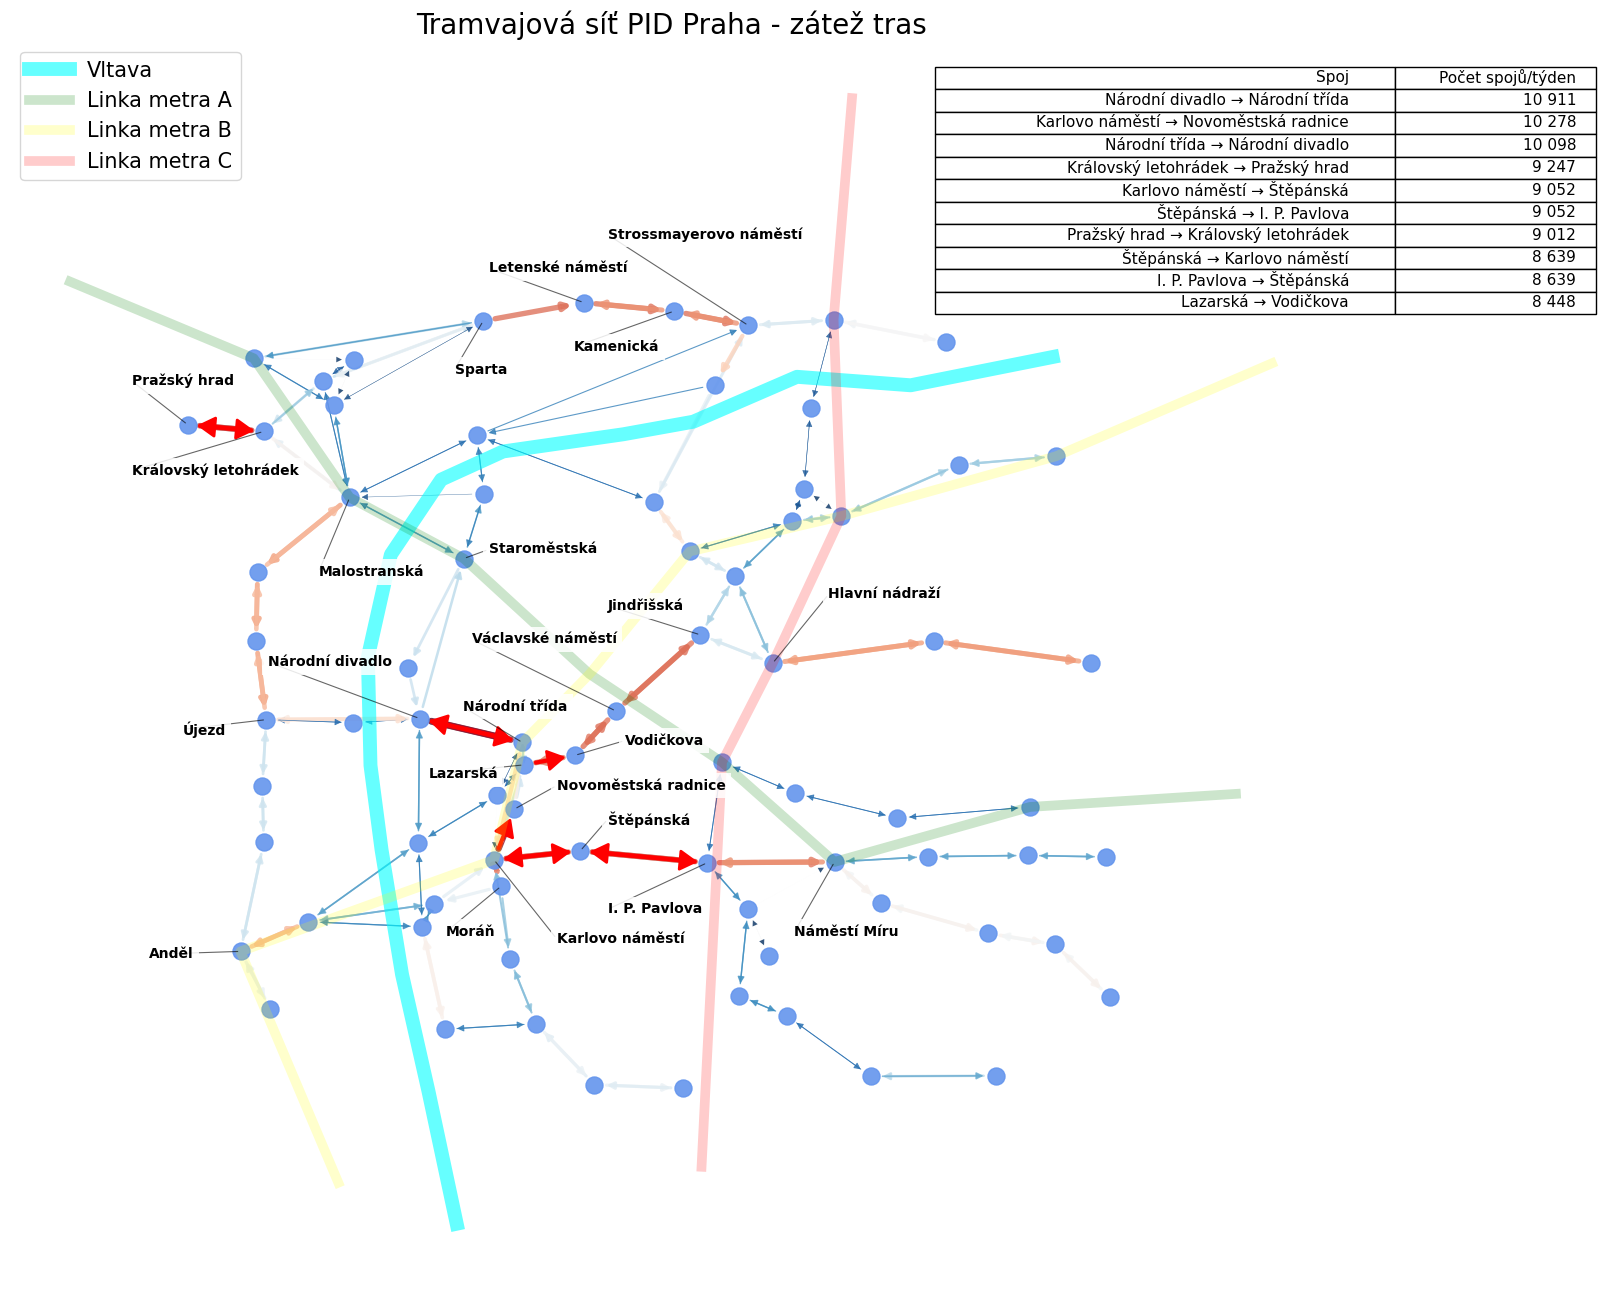

In [18]:
fig, ax = plt.subplots(figsize=(16, 13))

nx.draw_networkx_nodes(central_G, pos=central_pos, node_size=150, node_color='cornflowerblue', alpha=0.9)
nx.draw_networkx_edges(central_G, pos=central_pos, width=edge_widths, alpha=0.8, edge_color=edge_norm, edge_cmap=plt.cm.RdBu_r, arrows=True)

nx.draw_networkx_edges(central_G, pos=central_pos, edgelist=top_edges_list, width=2, edge_color='red', alpha=1,
                       arrowstyle=("simple, head_length=1.1, head_width=1.3, tail_width=0.1"))
####################################################################################################################################
for station, (label_x, label_y) in custom_points.items():
    node_x, node_y = pos_dict[station]
    
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y),
                arrowprops=dict(arrowstyle='-', color='black', lw=0.8, alpha=0.6))
    
    ax.text(label_x, label_y, station,
            fontsize=10, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))
####################################################################################################################################
table_data = [["Spoj", "Počet spojů/týden"]]
top_edges_clean = [(u, v, data['weight']) for u, v, data in top_edges]
for u, v, weight in top_edges_clean:
    table_data.append([f"{u} → {v}", f"{weight:,}".replace(",", " ")])

table = ax.table(cellText=table_data[1:],
                 colLabels=table_data[0],
                 cellLoc='right',
                 colLoc='right',
                 bbox=[0.7, 0.78, 0.5, 0.2],)

table.auto_set_column_width(col=[0, 1])
table.auto_set_font_size(False)
table.set_fontsize(11)
####################################################################################################################################
ax.plot(vltava_lons[12:26], vltava_lats[12:26], color='aqua', linewidth=10, alpha=0.6, label='Vltava')

ax.plot(stops_A['stop_lon'][4:13], stops_A['stop_lat'][4:13], color='green',  linewidth=7, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'][7:16], stops_B['stop_lat'][7:16], color='yellow', linewidth=7, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'][8:14], stops_C['stop_lat'][8:14], color='red',    linewidth=7, alpha=0.2, label='Linka metra C')
####################################################################################################################################
plt.title('Tramvajová síť PID Praha - zátež tras', fontsize=20)
plt.axis('off')
plt.legend(loc='upper left', fontsize=15)
plt.tight_layout()
plt.show()

Podobně jako u prvního grafu sledujeme počet tramvajových průchodů mezi dvěma stanicemi, čím více, tím je hrana hrubší a tmavší. Nejvíce průchodů je u Karlova náměstí a jeho okolí.

Jsou tady vidět i velké nepoměry. Můžeme si například všimnout velkého počtu průchodů mezi stanicemi Karlovo náměstí, I. P. Pavlova a pak i na Náměstí Míru, ale nízkého mezi stanicemi v jejich okolí. To by mohlo poukazovat na to, že hodně tramvají z různých tratí se tady seskupuje, aby pokryly vstupy do metra.

Většina spojů je vyvážená počtem průchodů na obě strany. Jsou tady ale i výjimky v nerovnováze, nebo třeba i spoje, které jezdí jenom jedním směrem (Karlovo náměstí → Novoměstská radnice nebo spoj mezi Národním divadlem a Staroměstskou).

### Míry centrality

Teď se lépe podíváme na uzly a jejich centralitu. Projdeme centralitu stupně, mezilehlosti a blízkosti. Vždy se taky podívame na neváženou a váženou variantu. U nevážene varianty jsou všechny hrany v siti považované za stejné, u váženych vypočtech ma každá hrana svoji váhu, v našem případe se jedna o počet tydenních průchodů.

#### Stupeň

Degree Centrality ukazuje, s kolika jinými uzly má uzel společnou hranu. U zastávek to bude poukazovat na to, kolik spojů existuje k zastávce a kolik průchodů projde zastávkou (příchody i odchody) za jeden týden. Bude tedy ukazovat zatíženost zastávky.

Tahle centralita je jako jediná lokální, bere v úvahu jenom spoje, které jsou s ní přímo spojené. Mezilehlost a blízkost jsou globální, pro jejich výpočet se používají všechny uzly v síti.

In [19]:
deg_in  = dict(G.in_degree(weight=None))
deg_out = dict(G.out_degree(weight=None))

deg_cent = nx.degree_centrality(G)

wdeg_in  = dict(G.in_degree(weight='weight'))
wdeg_out = dict(G.out_degree(weight='weight'))

wdeg_in_more  = {n: wdeg_in.get(n,0)  - wdeg_out.get(n,0) for n in G.nodes()}
wdeg_out_more = {n: wdeg_out.get(n,0) - wdeg_in.get(n,0) for n in G.nodes()}

# stejne jako 
# wdeg_tot = dict(G.degree(weight='weight'))
wdeg_tot = {n: wdeg_in.get(n,0) + wdeg_out.get(n,0) for n in G.nodes()}

In [20]:
def print_cent ( cent, top, text ):
    tmp = sorted(cent.items(), key=lambda x: x[1], reverse=True)[:top]
    
    name_width = max(len(n) for n, _ in tmp)
    num_width = 10

    print(f"{text}:\n")
    for n, m in tmp:
        print(f"\t{n + ':':<{name_width+1}} {round(m,2):>{num_width},}".replace(",", " "))

#print_cent(deg_in,  5, 'Nevážený stupeň vstupu')
#print('\n')
#print_cent(deg_out, 5, 'Nevážený stupeň výstupu')
#print('\n')
#print_cent(deg_cent, 10, 'Normalizovaný stupeň uzlú')
#print('\n')
#print_cent(wdeg_tot, 10, 'Vážený stupeň uzlú')
#print('\n')
#print_cent(wdeg_in_more,  5, 'Více vážených vstupú')
#print('\n')
#print_cent(wdeg_out_more, 5, 'Více vážených výstupu')

![deg_cent.png](images/deg_cent.png)

U neváženého stupně vidíme, že zastávky jako Malostranská a Náměstí Bratří Synků jsou topologicky nejpropojenější. Slouží největšímu počtu různých přímých segmentů sítě, čímž poskytují flexibilitu pro přestupy na různé linky. (Uvidíme, jestli to tak bude i u dalších centralit.)

U váženého stupně výsledky nejsou tak odlišné, některé stanice se objevili u obou typu vypočtů. Karlovo náměstí je jednoznačně nejdůležitější zastávkou z hlediska celkového objemu provozu. Za jeden týden tudy projde až 55 236 tramvají. Zatímco Malostranská má nejvíce různých spojení, Karlovo náměstí, Anděl a Národní divadlo přijimají a distribuují největší počet spojů. To by mohlo signalizovat, že tyto centrální uzly tvoří hlavní kapacitní koridory (např. spojovací trasy a centra) s velmi hustým jízdním řádem a jsou tedy kritické pro plynulý chod sítě.

U stupně s více vstupy se často jedná o sídlištní terminály nebo vozovny, kam spoje přijíždějí, vysazují cestující a jízdu buď ukončují, nebo ji zahajují v protisměru. A pro více výstupů to jsou obratiště a konečné stanice, kde linky zahajují svůj provoz.

#### Between

Betweenness Centrality měří, kolikrát leží uzel na nejkratší cestě mezi všemi páry uzlů v síti. Poukazuje na to, jak je uzel průchodný. Zastávky, které se objevují často, budou mít vyšší hodnotu.

Tady si ale musíme dát pozor na 'weight' u výpočtu centrality. Ta reprezentuje 'distance', vzdálenost k cíli, čím menší, tím lepší. Naše weight ale reprezentuje počet spojů mezi zastávkami, čím více spojů, tím rychleji se dostaneme na další zastávku. Tudíž je to naopak. Proto si vytvoříme novou hodnotu frequency, která by měla lépe reprezentovat realitu.

In [21]:
for u, v, data in G.edges(data=True):
    data['frequency'] = 1 / data['weight']

between_cent_norm = nx.betweenness_centrality(G, weight=None, normalized=True)
between_cent_freq = nx.betweenness_centrality(G, weight=None, normalized=False)

between_cent_norm_top = sorted(between_cent_norm.items(), key=lambda x: x[1], reverse=True)[:10]
between_cent_freq_top = sorted(between_cent_freq.items(), key=lambda x: x[1], reverse=True)[:10]

#print('Centralita mezilehlosti - jenom strukturálne:\n')

#for i, (name, value) in enumerate(between_cent_freq_top):
#    name = name + ':'
#    print(f"\t{name:<22}\t{round(value):,} ({round(between_cent_norm_top[i][1] * 100)}%)".replace(",", " "))

between_cent_norm = nx.betweenness_centrality(G, weight='frequency', normalized=True)
between_cent_freq = nx.betweenness_centrality(G, weight='frequency', normalized=False)

between_cent_norm_top = sorted(between_cent_norm.items(), key=lambda x: x[1], reverse=True)[:10]
between_cent_freq_top = sorted(between_cent_freq.items(), key=lambda x: x[1], reverse=True)[:10]

#print('Centralita mezilehlosti - podle frekvence:\n')

#for i, (name, value) in enumerate(between_cent_freq_top):
#    name = name + ':'
#    print(f"\t{name:<22}\t{round(value):,} ({round(between_cent_norm_top[i][1] * 100)}%)".replace(",", " "))

![bet_cent.png](images/bet_cent.png)

V nevážené variantě byly patří mezi nejdůležitějšími zastávky například Malostranská, Národní divadlo a Čechův most. Z topologického hlediska tyto zastávky se objevuji na velkém množství nejkratších cest a mají důležitou roli v propojováni jiních časti sítě. Většina tyhle zastávek se nacházi v centru nebo jeho blízkosti.

Ve vážené variantě byly výsledky odlišné: vyšší význam získaly zastávky jako Karlovo náměstí, Strossmazerovo náměsti nebo Vltaská která se predtím neobjevila, zatím co Malostranská hodně klesla. V této verzi totiž nejkratší cesty preferují úseky s častějším provozem, protože jsou považovány za snáze dosažitelné. Karlovo náměstí je znovu na nejlpeší pozici a opakují se nám zastávky jako Strossmayerovo náměstí a Palmovka.

Porovnáním obou přístupů vidíme, že některé uzly i když jsou strukturálně centrální, jejich provozní význam se může hodně lišít. 

#### Closeness

Closeness Centrality měří průměrnou vzdálenost dané zastávky ke všem ostatním zastávkám v síti. V našem případe to predstavuje kvalitu umistení zastávky v síti. Vysokou hodnotu budou mít zastávky z kterých se mužeme rychle dostat do jiných.

Tady je znovu pro výpočet duležitá vzdálenost hrany.

In [22]:
closeness_centrality_freq     = nx.closeness_centrality(G, distance='frequency')
closeness_centrality_freq_top = sorted(closeness_centrality_freq.items(), key=lambda x: x[1], reverse=True)[:10]

#print('Centralita blízkosti - podle frekvence:\n')
#for name, value in closeness_centrality_freq_top:
#    name = name + ':'
#    print(f"\t{name:<22}\t{round(value):,}".replace(",", " "))

closeness_centrality    = nx.closeness_centrality(G)
closeness_centrality_top = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

#print('Centralita blízkosti - jenom strukturálne:\n')
#for name, value in closeness_centrality_top:
#    name = name + ':'
#    print(f"\t{name:<22}\t{value:,.03f}".replace(",", " "))

![clo_cent.png](images/clo_cent.png)

Nevážena blízkost ignoruje, jestli spoje jezdí často nebo ne, proto se tady vyskytuji zastavky z centra mesta ktere v průměru potřebujejí méně přestupů nez ty ktere jsou na okrajich siti. Jsou tady ty samy zastavky které jsme uz nekolik krat videli u nevážených variant.

Vazene zastávky maji k ostatním zastávkám nejblize kvůli vysoké hustote site a frekvenci spojů, které zkracují čekací doby a dělají síť efektivni. Znovu nam tady odpadlo hodne zastávek a polepšili si jiné. Po třetí je Karlovo náměstí nejlepší ale ztatili jsme zastávky Strossmayerovo náměstí a Palmovku. A objeviji se tady nově třeba Lazarská a Štěpánská, které se obje vyskztuji v blízkosti Karlovho náměstí. Co nám naznačuje, že se jedná o lokalitu s nejefektivnejší dopravou.

#### Shrnuti mír centralit

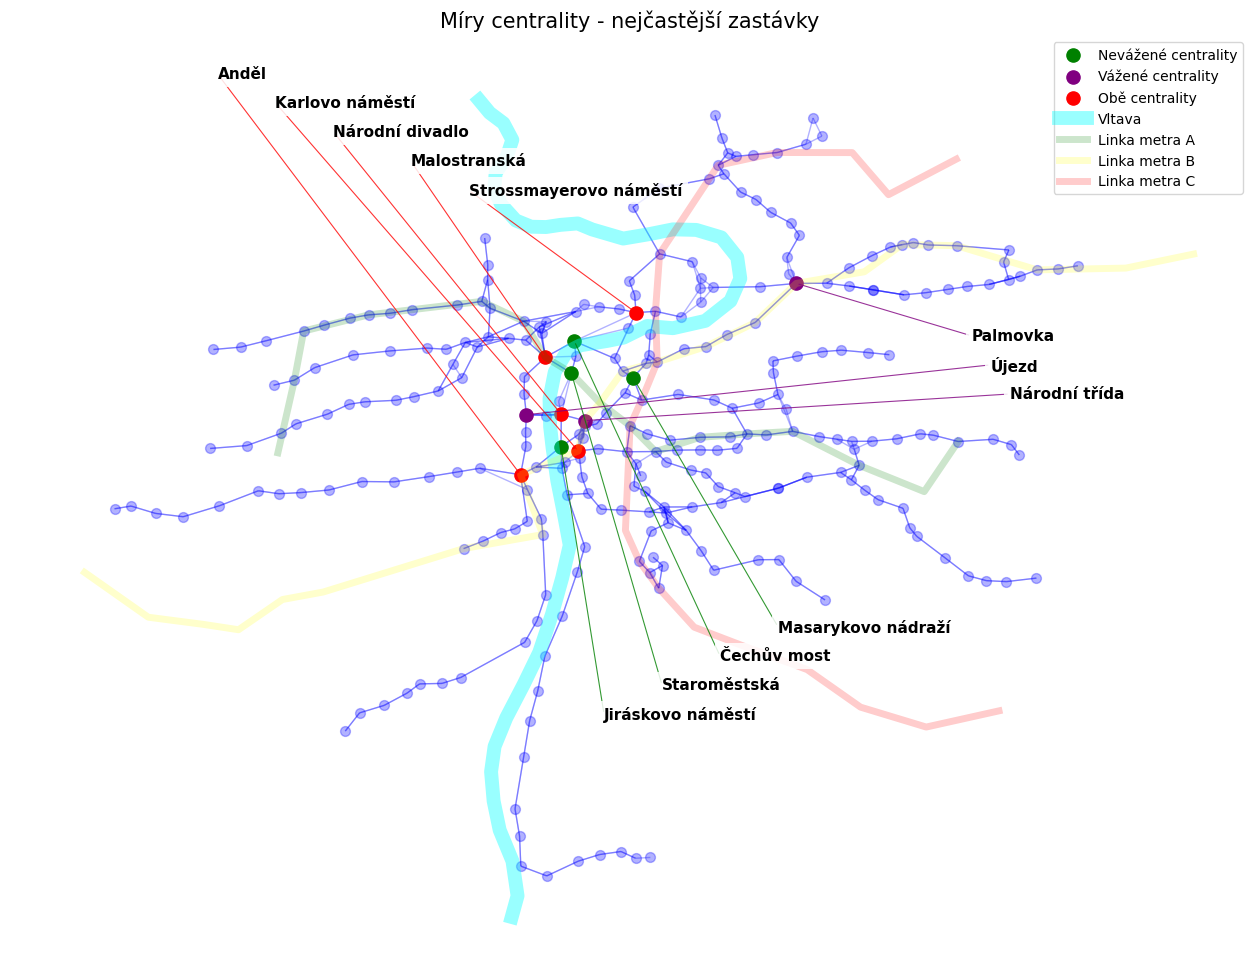

In [23]:
nodes_both = ['Anděl', 'Karlovo náměstí', 'Národní divadlo', 'Malostranská', 'Strossmayerovo náměstí']
nodes_none = ['Čechův most', 'Jiráskovo náměstí', 'Masarykovo nádraží', 'Staroměstská']
nodes_freq = ['Palmovka', 'Národní třída', 'Újezd']

custom_points_both = {
    'Anděl':                  (14.325,  50.140),
    'Karlovo náměstí':        (14.340,  50.135),
    'Národní divadlo':        (14.355,  50.130),
    'Malostranská':           (14.375,  50.125),
    'Strossmayerovo náměstí': (14.390,  50.120),
}

custom_points_none = {
    'Masarykovo nádraží': (14.470, 50.045),
    'Čechův most':        (14.455, 50.040),
    'Staroměstská':       (14.440, 50.035),
    'Jiráskovo náměstí':  (14.425, 50.030),
}

custom_points_freq = {
    'Palmovka':      (14.520, 50.095),
    'Újezd':         (14.525, 50.090),
    'Národní třída': (14.530, 50.085),
}

fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_nodes(G, pos=pos_dict, node_size=50, node_color='blue', alpha=0.3)
nx.draw_networkx_edges(G, pos=pos_dict, width=1, alpha=0.3, edge_color='blue', arrows=False)

nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=nodes_none, node_size=90, node_color='green',  alpha=1, label='Nevážené centrality')
nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=nodes_freq, node_size=90, node_color='purple', alpha=1, label='Vážené centrality')
nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=nodes_both, node_size=90, node_color='red',    alpha=1, label='Obě centrality')

for station, (label_x, label_y) in custom_points_both.items():
    node_x, node_y = pos_dict[station]
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='red', lw=0.8, alpha=0.8))
    ax.text(label_x, label_y, station, fontsize=11, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

for station, (label_x, label_y) in custom_points_none.items():
    node_x, node_y = pos_dict[station]
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='green', lw=0.8, alpha=0.8))
    ax.text(label_x, label_y, station, fontsize=11, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

for station, (label_x, label_y) in custom_points_freq.items():
    node_x, node_y = pos_dict[station]
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='purple', lw=0.8, alpha=0.8))
    ax.text(label_x, label_y, station, fontsize=11, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.4, label='Vltava')

ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

plt.title('Míry centrality - nejčastější zastávky', fontsize=15)
plt.axis('off')
plt.legend()
plt.show()

Podívali jsme se na tři druhy centrality (stupeň, mezilehlost a blízkost) pomocí dvou typů výpočtů (topologicky a frekvenčně).

Na grafu vidíme nejčastěji se objevující zastávky a jejich rozdělení podle role:

- Zelená – zastávky s vysokou četností u nevážených výpočtů
  - mají velmi důležitou topologickou pozici a propojují významné části sítě

- Fialová – zastávky s vysokou četností u vážených výpočtů
  - jedná se o přestupní stanice, které potřebují rychlé a efektivní spojení

- Červená – zastávky s vysokou četností u obou výpočtů
  - klíčové body kombinující vysokou frekvenci i důležitou polohu

Z topologického hlediska vychází jako nejdůležitější zastávka Malostranská, která by teoreticky mohla sehrávat významnou roli i z hlediska spojů a frekvence. Přesto si myslím, že zde existují zastávky, které lze považovat za důležitější. Malostranská sice propojuje více částí sítě, ale ne ty úplně klíčové, a její provoz, byť vysoký, není nejvyšší.

Z hlediska skutečné zátěže je nejdůležitější Karlovo náměstí, které podle mě lépe odpovídá realitě. Leží v hustě využívané oblasti, odráží to nejvyšší počet průjezdů, propojuje hlavní části Prahy a zároveň navazuje i na další dopravní prostředky.

Také jsme si mohli všimnout, že u nevážených hodnot se stejné zastávky objevovaly velmi často, zatímco u vážených výpočtů se pořadí zastávek více střídalo. To může naznačovat, že vážené hodnoty poskytují realističtější popis skutečné důležitosti zastávek, protože zohledňují více kritérií než jen samotnou topologickou strukturu.

#### Vizualizace mezilehlosti

Nakonec si vytvoříme vizualizaci mezilehlosti. Tato míra centrality by v našem případě měla nejlépe vystihovat skutečnou důležitost zastávky, protože ukazuje, na kolika nejkratších cestách v celé síti daná zastávka leží. Identifikuje uzly, které nejčastěji slouží jako přestupní nebo průchozí body mezi různými částmi sítě. Právě tyto zastávky by měly být klíčové pro celkovou plynulost provozu a organizaci tramvajové dopravy.

![bet_cent_map.png](images/bet_cent_map.png)

Na obrázku je dobře vidět, jak se mění důležitost jednotlivých zastávek v rámci sítě.

U odlehlejších linek můžeme například pozorovat, že s rostoucí vzdáleností od centra a s menším počtem navazujících spojů klesá jejich mezilehlost. Když dojde k poruše na koncové zastávce, neovlivní to zdaleka tolik cest než výpadek v centru nebo na některém z hlavních přestupních uzlů.

Zároveň si můžeme všimnout, zejména v oblasti linky B, že tramvajové linky vedené souběžně s metrem mají nižší míru mezilehlosti než jejich alternativy vedoucí mimo trasu metra. To odráží skutečnost, že část přepravní poptávky absorbuje metro, takže tramvajové spoje v těchto úsecích nejsou tak kritické pro celkovou průchodnost sítě.

Pokračujme tedy podrobnější analýzou.

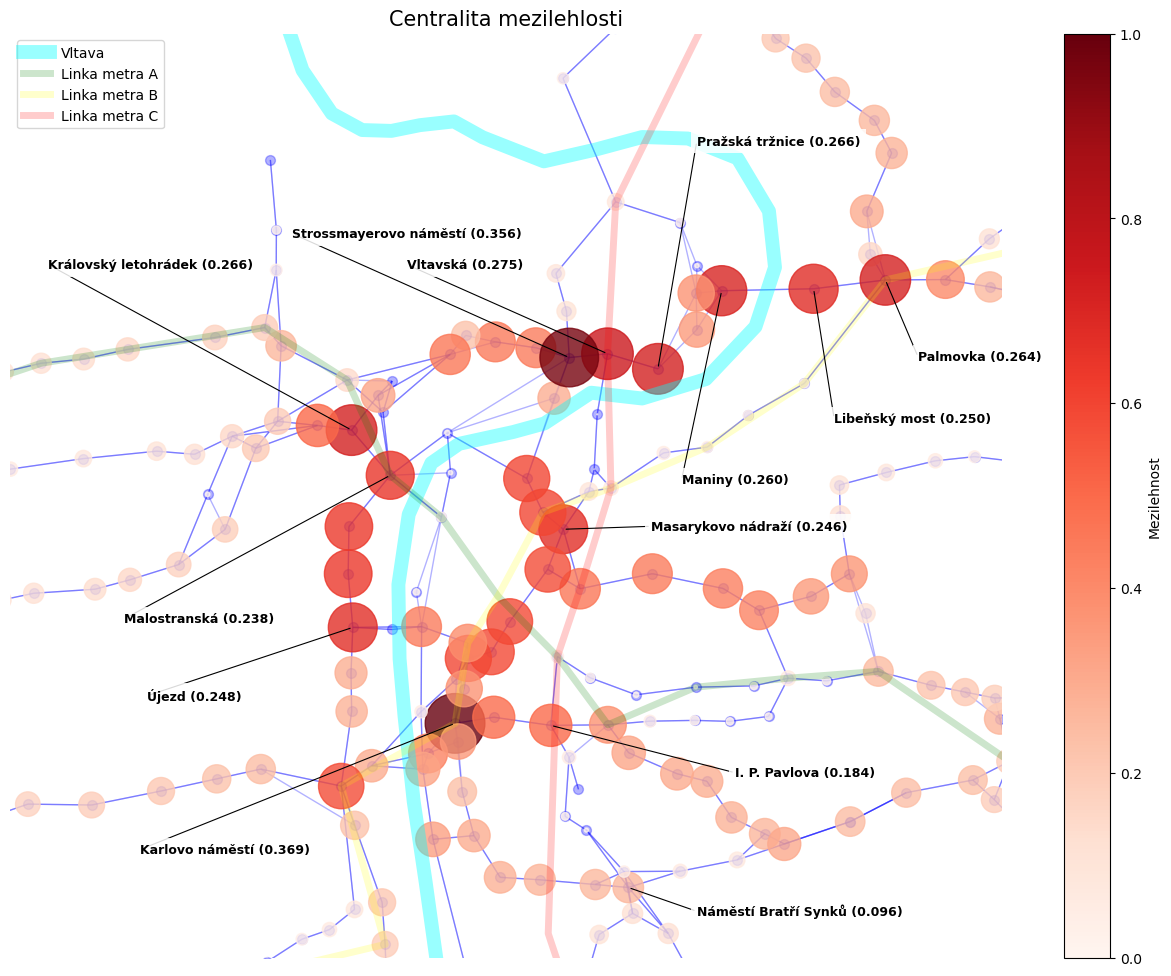

In [24]:
# horní obrazek je stejný kód ale bez omezení os

fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_nodes(G, pos=pos_dict, node_size=50, node_color='blue', alpha=0.3)
nx.draw_networkx_edges(G, pos=pos_dict, width=1, alpha=0.3, edge_color='blue', arrows=False)

node_sizes = [between_cent_norm.get(node, 0) * 5000 for node in G.nodes()]
node_colors = [between_cent_norm.get(node, 0) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos=pos_dict, node_size=node_sizes, node_color=node_colors, cmap='Reds', alpha=0.8)

top_nodes = sorted(between_cent_norm.items(), key=lambda x: x[1], reverse=True)[:10]
custom_points = {
    top_nodes[0][0]: (14.377, 50.067), # karl
    top_nodes[1][0]: (14.397, 50.107), # stross
    top_nodes[2][0]: (14.412, 50.105), # vlt
    top_nodes[3][0]: (14.450, 50.113), # praz trzn
    top_nodes[4][0]: (14.365, 50.105), # hradek
    top_nodes[5][0]: (14.479, 50.099), # palm
    top_nodes[6][0]: (14.448, 50.091), # maniny
    top_nodes[7][0]: (14.468, 50.095), # liben most
    top_nodes[8][0]: (14.378, 50.077), # ujezd
    top_nodes[9][0]: (14.444, 50.088), # mass
    'Malostranská':  (14.375, 50.082),
    'I. P. Pavlova': (14.455, 50.072),
    'Náměstí Bratří Synků': (14.450, 50.063),
}
for station, (label_x, label_y) in custom_points.items():
    if station in pos_dict:
        node_x, node_y = pos_dict[station]
        ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='black', lw=0.8))
        ax.text(label_x, label_y, f"{station} ({between_cent_norm[station]:.3f})", fontsize=9, fontweight='bold', ha='left', va='center',
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.4, label='Vltava')

ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

ax.set_xlim([14.36, 14.49])
ax.set_ylim([50.06, 50.12])

plt.title('Centralita mezilehlosti', fontsize=15)
plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), ax=ax, label='Mezilehnost')
plt.axis('off')
plt.legend()
plt.show()

V přiblíženém pohledu můžeme vidět, že západní strana Vltavy (úsek Újezd – Malostranská) je výrazně vytíženější než strana východní. Tato oblast sice není historickým centrem, ale nachází se zde hustě obydlené čtvrti i významné přestupní uzly, takže lidé v této části města využívají tramvaje mnohem intenzivněji než v samotném starém městě.

Opět můžeme sledovat sníženou frekvenci u linek vedených souběžně s metrem. Tramvajové spoje v těchto úsecích slouží spíše jako doplňková doprava a část přepravní poptávky tak přebírá metro. Naopak lze snadno identifikovat úseky s vysokou i nízkou zátěží, například spojení I. P. Pavlova - Náměstí Bratří Synků patří k těm výrazně nevytíženým.

Také si všimneme, že dvě zastávky s nejvyšší mezilehlostí leží uprostřed velkých shluků s vysokou frekvencí. Jde tedy o skutečně klíčové, silně zatížené uzly, které hrají zásadní roli v efektivním fungování celé tramvajové sítě.

### Otázky

#### 1. Otázka
#### Mění se důležité zastávky v závislosti na denním/nočním provozu?

Rozdelíme si dataset na denní a noční provoz, zjistíme kolik krát se různe zastávky v nich vyskytují a tyhle výsledky porovnáme.

In [25]:
tram_day   = tram_timetables[tram_timetables['is_night'] == 0]
tram_night = tram_timetables[tram_timetables['is_night'] == 1]

day_rank   = pd.concat([tram_day['stop_from_name'],   tram_day['stop_to_name']]).value_counts().head(20)
night_rank = pd.concat([tram_night['stop_from_name'], tram_night['stop_to_name']]).value_counts().head(20)

top_stops_day   = day_rank.index.tolist()
top_stops_night = night_rank.index.tolist()

top_both       = list(set(top_stops_day)   & set(top_stops_night))
top_day_only   = list(set(top_stops_day)   - set(top_stops_night))
top_night_only = list(set(top_stops_night) - set(top_stops_day))

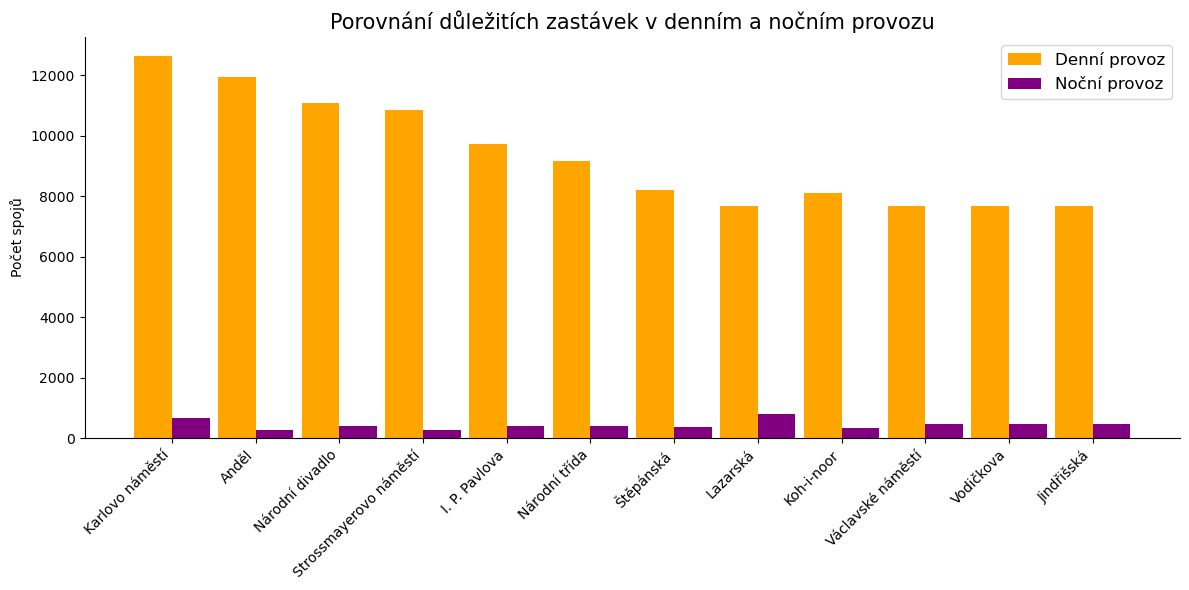

Denní provoz tvoří 95.9% a noční 4.1% spojů (z 281 zastávek a celkem 190156 spojů).


In [26]:
day_rank_dt   = dict(day_rank)
night_rank_dt = dict(night_rank)

sorted_stops = sorted(top_both, key=lambda s: day_rank_dt[s] + night_rank_dt[s], reverse=True)

total_day = sum(day_rank_dt.get(s, 0) for s in all_stops)
total_night = sum(night_rank_dt.get(s, 0) for s in all_stops)
total = total_day + total_night

if total == 0:
    day_pct = night_pct = 0.0
else:
    day_pct = total_day / total * 100.0
    night_pct = total_night / total * 100.0

x = np.arange(len(sorted_stops))
width = 0.45

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, [day_rank_dt[s] for s in sorted_stops],   width, label='Denní provoz', color='orange')
ax.bar(x + width/2, [night_rank_dt[s] for s in sorted_stops], width, label='Noční provoz', color='purple')

ax.set_ylabel('Počet spojů')
ax.set_title('Porovnání důležitích zastávek v denním a nočním provozu', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(sorted_stops, rotation=45, ha='right')
ax.legend(fontsize=12)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 

plt.tight_layout()
plt.show()

#print('Top 10 denních zastávek:\n')
#display(day_rank[:10])

#print('Top 10 nočních zastávek:\n')
#display(night_rank[:10])

print(f"Denní provoz tvoří {day_pct:.1f}% a noční {night_pct:.1f}% spojů (z {len(all_stops)} zastávek a celkem {total} spojů).")

![day_night.png](images/day_night.png)

Na první pohled je vidět obrovský rozdíl mezi denním a nočním provozem. Zjistili jsme, že noční provoz tvoří přibližně jen 4 % všech spojů, což přesně odpovídá výrazně omezenému rozsahu noční sítě. Hlavním zjištěním ale je, že se zásadně mění tramvajové tratě a zastávky.

Zastávky, které se v předchozích analýzách pravidelně objevovaly jako důležité (Anděl, Strossmayerovo náměstí, Malostranská, Pražský hrad nebo Královský letohrádek), v noční síti mizí. Naopak se objevují nové uzly (Lazarská, Jindřišská, Václavské náměstí, Vodičkova) které v nočním provozu výrazně rostou na významu.

Nyní se ještě stručně podíváme na geografické rozmístění nejdůležitějších zastávek během dne a noci, abychom porovnali, kde přesně se těžiště sítě v jednotlivých obdobích nachází.

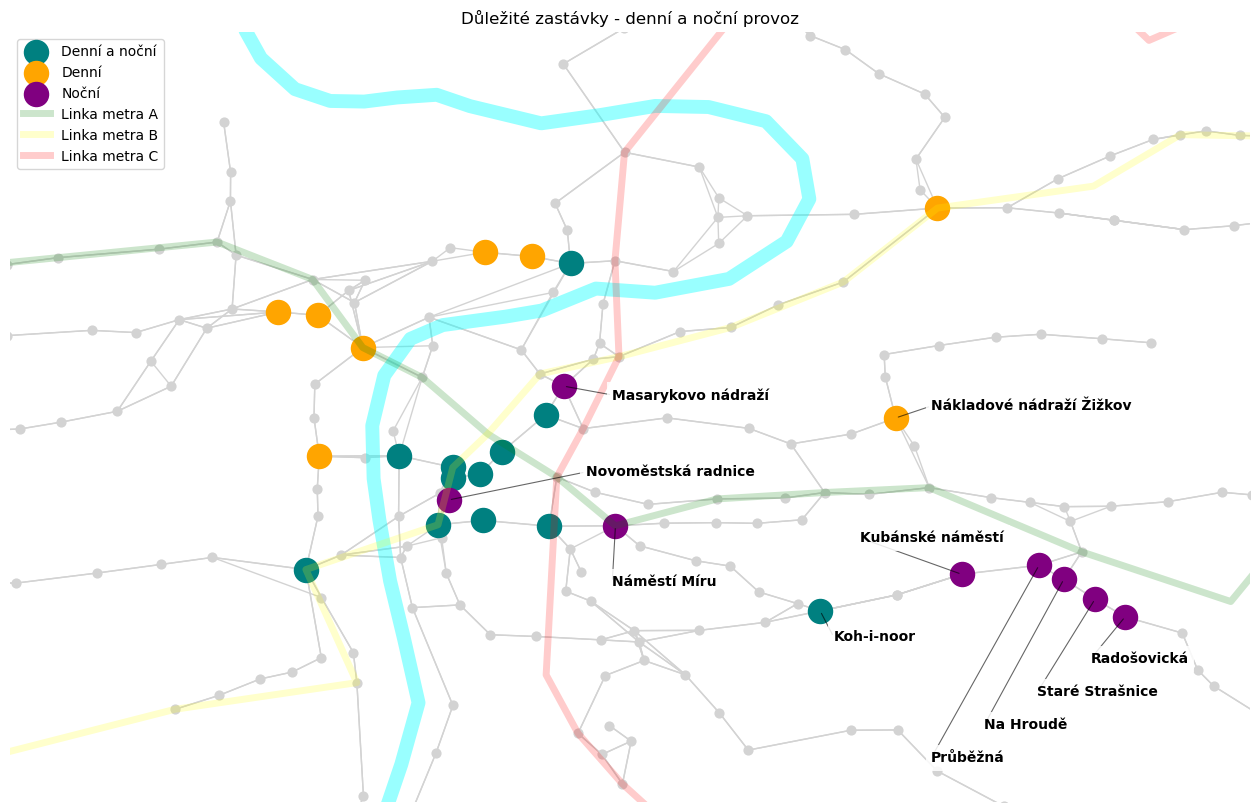

In [27]:
custom_points = {
    'Nákladové nádraží Žižkov': (14.474, 50.086),
    'Koh-i-noor':               (14.463, 50.065),
    'Radošovická':              (14.492, 50.063),
    'Staré Strašnice':          (14.486, 50.060),
    'Na Hroudě':                (14.480, 50.057),
    'Průběžná':                 (14.474, 50.054),
    'Kubánské náměstí':         (14.466, 50.074),
    'Masarykovo nádraží':       (14.438, 50.087),
    'Náměstí Míru':             (14.438, 50.070),
    'Novoměstská radnice':      (14.435, 50.080)
}

fig, ax = plt.subplots(figsize=(16, 10))

nx.draw(G, pos=pos_dict, node_size=40, node_color='lightgray', edge_color="lightgray", arrows=False)

nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=top_both,       node_size=300, node_color='teal',   label='Denní a noční')
nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=top_day_only,   node_size=300, node_color='orange', label='Denní')
nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=top_night_only, node_size=300, node_color='purple', label='Noční')

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.4)
ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

for station, (label_x, label_y) in custom_points.items():
    node_x, node_y = pos_dict[station]
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='black', lw=0.8, alpha=0.6))
    ax.text(label_x, label_y, station,fontsize=10, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

ax.set_xlim([14.37, 14.51])
ax.set_ylim([50.05, 50.12])

plt.title('Důležité zastávky - denní a noční provoz')
plt.axis("off")
plt.legend()
plt.show()

Pro lepší vizualizaci se podívame na širší okruh spojů. Vidíme, že během dne jsou nejdůležitější tramvajové zastávky soustředěné především v centru, v okolí Pražského hradu, ale také na významných uzlech jako Nákladové nádraží Žižkov nebo Palmovka.

V noci se však těžiště sítě výrazně přesouvá, klíčové zastávky se posouvají do východní části města, zejména podél trasy metra A. Noční tramvajové linky jsou totiž vedeny převážně přes centrum a spoléhají na několik silných přestupních míst, kolem kterých se celá noční síť soustředí.

Můžeme tedy jednoznačně říci, že během dne a noci se důležité zastávky mění.

#### 2. Otázka
#### Je rozdíl ve vytíženosti zastávek během pracovního týdne/víkendu?

Podobne jako u první otázky, rozdelíme si dataset na pracovní týden a vkend, zjistíme jaky mají provoz různe zastávky a ty pak porovnáme.

In [28]:
tram_timetables['workday_trips'] = (
    tram_timetables['monday'] + tram_timetables['tuesday'] +
    tram_timetables['wednesday'] + tram_timetables['thursday'] +
    tram_timetables['friday']
)

tram_timetables['weekend_trips'] = (tram_timetables['saturday'] + tram_timetables['sunday'])

workday_usage = (tram_timetables.groupby(['stop_from_name'])['workday_trips'].sum() +
                 tram_timetables.groupby(['stop_to_name'])['workday_trips'].sum()).sort_values(ascending=False).fillna(0)

weekend_usage = (tram_timetables.groupby(['stop_from_name'])['weekend_trips'].sum() +
                 tram_timetables.groupby(['stop_to_name'])['weekend_trips'].sum()).sort_values(ascending=False).fillna(0)

In [29]:
top_stops_work = workday_usage.index.tolist()
top_stops_end  = weekend_usage.index.tolist()

top_both = list(set(top_stops_work) & set(top_stops_end))

workday_usage_dt = dict(workday_usage)
weekend_usage_dt = dict(weekend_usage)

sorted_stops = sorted(top_both, key=lambda s: workday_usage_dt[s] + weekend_usage_dt[s], reverse=True)[:10]

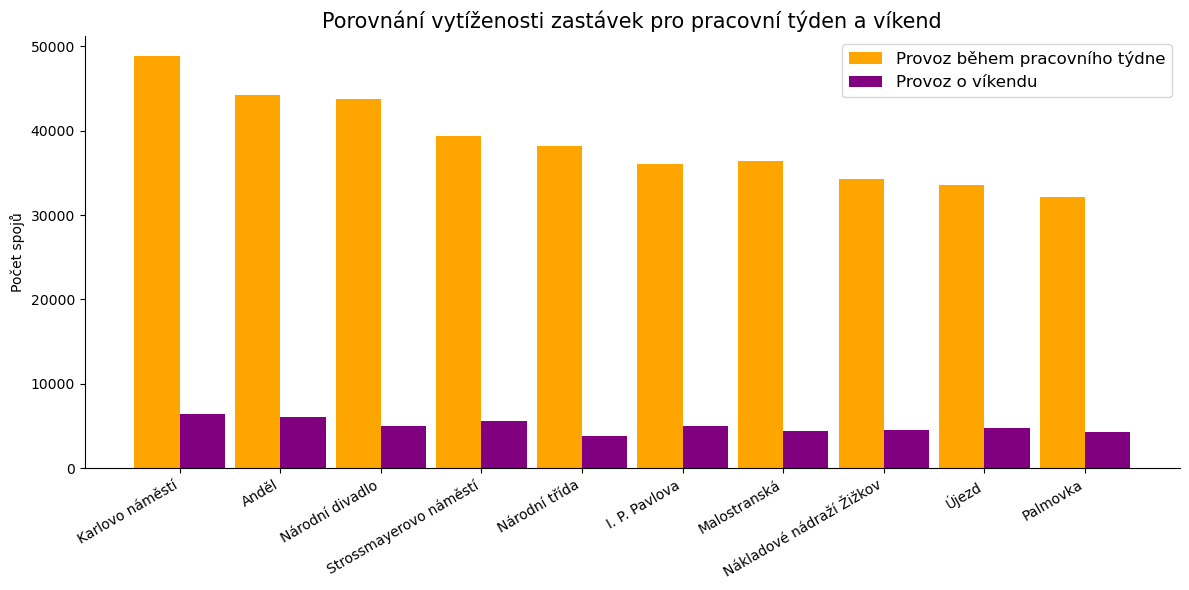

Celkový počet spojů v pracovním týdnu: 2111285
Celkový počet spojů o víkendu:	       275754
Pokles:			               1835531

Pokles provozu o víkendu oproti pracovním dnům:

		86.94%


In [30]:
x = np.arange(len(sorted_stops))

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, [workday_usage_dt[s] for s in sorted_stops], width, color='orange', label='Provoz během pracovního týdne')
ax.bar(x + width/2, [weekend_usage_dt[s] for s in sorted_stops], width, color='purple', label='Provoz o víkendu')

ax.set_ylabel('Počet spojů')
ax.set_title('Porovnání vytíženosti zastávek pro pracovní týden a víkend', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(sorted_stops, rotation=30, ha='right')
ax.legend(fontsize=12)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False) 

plt.tight_layout()
plt.show()

#print('Top 10 vyteženích zastávek behěm pracovníh týdne:\n')
#display(workday_usage[:10])
#print('\n')
#print('Top 10 vyteženích zastávek behěm víkendu:\n')
#display(weekend_usage[:10])

total_workday_trips = tram_timetables['workday_trips'].sum()
total_weekend_trips = tram_timetables['weekend_trips'].sum()

difference = total_workday_trips - total_weekend_trips
percent_drop = difference / total_workday_trips * 100

print("Celkový počet spojů v pracovním týdnu:", int(total_workday_trips))
print("Celkový počet spojů o víkendu:\t      ", int(total_weekend_trips))
print("Pokles:\t\t\t              ", int(difference))
print("\nPokles provozu o víkendu oproti pracovním dnům:\n\n\t\t{:.2f}%".format(percent_drop))

![week_end.png](images/week_end.png)

Stejně jako u první otázky pozorujeme výrazný rozdíl mezi kategoriemi, během víkendu dochází k poklesu počtu spojů téměř o 87 % oproti pracovnímu týdnu.
Na rozdíl od předchozího případu však platí, že zastávky s vysokým počtem průchodů během pracovních dnů bývají nejfrekventovanější i o víkendu. Zátěž se tedy výrazně změní v absolutních hodnotách, ale relativní význam hlavních uzlů zůstává podobný.

Ještě se pokusíme zjistit, zda existují zastávky, které mají vyšší zátěž o víkendu než ve všední dny.

Zastávky s větším provozem během pracovních dnů (top 15):
['Karlovo náměstí', 'Národní divadlo', 'Anděl', 'Národní třída', 'Strossmayerovo náměstí', 'Malostranská', 'I. P. Pavlova', 'Nákladové nádraží Žižkov', 'Újezd', 'Palmovka', 'Štěpánská', 'Koh-i-noor', 'Pražský hrad', 'Královský letohrádek', 'Lazarská']

Zastávy s větším provozem o víkendu (top 15):
['Zvonařka']


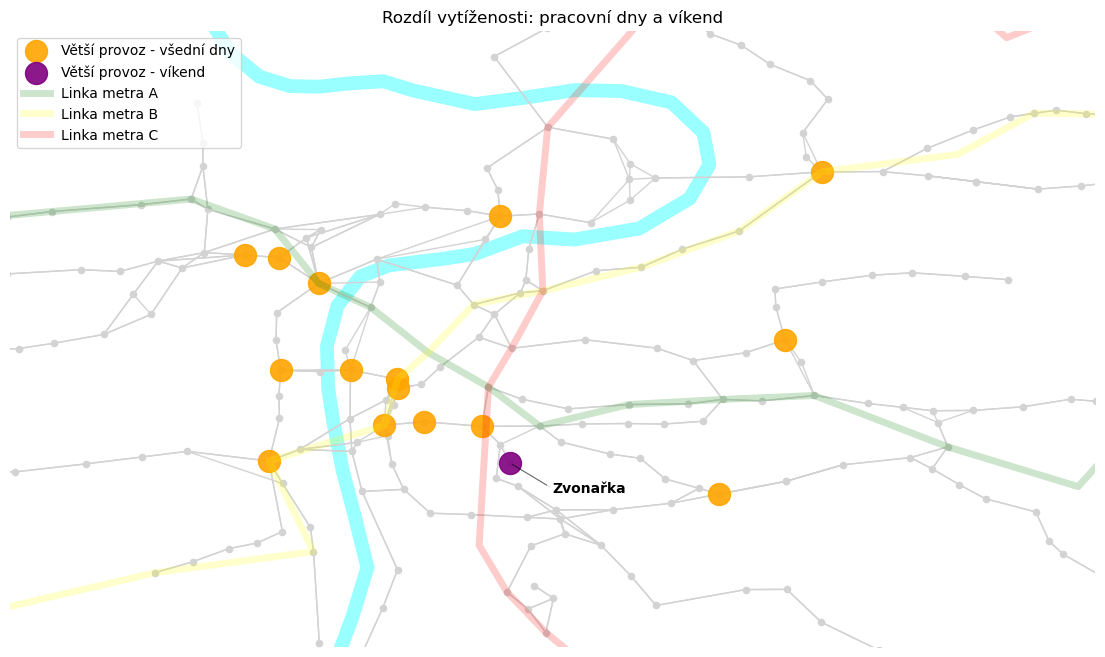

In [31]:
diff = workday_usage - weekend_usage

top_workday_more = diff[diff > 0].sort_values(ascending=False)
top_weekend_more = diff[diff < 0].sort_values(ascending=True)

topN = 15
top_workday_more_list = top_workday_more.head(topN).index.tolist()
top_weekend_more_list = top_weekend_more.head(topN).index.tolist()

print("Zastávky s větším provozem během pracovních dnů (top {}):".format(topN))
print(top_workday_more_list)
print("\nZastávy s větším provozem o víkendu (top {}):".format(topN))
print(top_weekend_more_list)

n_with_pos = [n for n in all_stops if n in pos_dict]

work_nodes   = [n for n in top_workday_more_list if n in pos_dict]
weekend_nodes= [n for n in top_weekend_more_list if n in pos_dict]

custom_points = {
    'Zvonařka': (14.440, 50.068),
}

fig, ax = plt.subplots(figsize=(14, 8))

nx.draw(G, pos=pos_dict, node_size=20, node_color='lightgray', edge_color="lightgray", arrows=False)

nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=work_nodes,    node_size=250, node_color='orange', alpha=0.9, label='Větší provoz - všední dny')
nx.draw_networkx_nodes(G, pos=pos_dict, nodelist=weekend_nodes, node_size=250, node_color='purple', alpha=0.9, label='Větší provoz - víkend')

for station, (label_x, label_y) in custom_points.items():
    node_x, node_y = pos_dict[station]
    ax.annotate('', xy=(label_x, label_y), xytext=(node_x, node_y), arrowprops=dict(arrowstyle='-', color='black', lw=0.8, alpha=0.6))
    ax.text(label_x, label_y, station,fontsize=10, fontweight='bold', ha='left', va='center',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.4, zorder=0)
ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

ax.set_xlim([14.37, 14.51])
ax.set_ylim([50.05, 50.12])

plt.title('Rozdíl vytíženosti: pracovní dny a víkend')
plt.axis("off")
plt.legend(loc='upper left')
plt.show()

Zvonařka je jedinou tramvajovou zastávkou, která má více průchodů o víkendu než během pracovních dnů. Důvodem je provoz historické tramvaje, která na této trase jezdí častěji právě o víkendech.

![line23.png](images/line23.png)

Pro zodpovězení otázky tedy můžeme říct, že zátěž se o víkendu výrazně snižuje, ale relativní význam klíčových uzlů zůstává velmi podobný.

#### 3. Otázka
#### Jak spolu souvisí tramvajová a autobusová doprava ?

Abych zjistil, jak spolu souvisí tramvajová a autobusová doprava z pohledu zátěže a významu uzlů, provedl jsem výpočet mezilehlostní centrality pro autobusovou síť. Následně jsem porovnal výsledné nejdůležitější zastávky s těmi tramvajovými a obě sítě jsem vykreslil na mapě.

Mezilehlostní centralita je vhodná, protože zachycuje, kolikrát uzel leží na nejkratších cestách mezi ostatními zastávkami. To v kontextu MHD výborně vystihuje, jak moc je zastávka využívaná jako přestupní nebo průjezdový bod.

In [106]:
bus_timetables = timetables[timetables['route_type'] == 3].copy()

bus_timetables['weekly_trips'] = (
    bus_timetables['monday'] + bus_timetables['tuesday'] + bus_timetables['wednesday'] +
    bus_timetables['thursday'] + bus_timetables['friday'] + bus_timetables['saturday'] +
    bus_timetables['sunday']
)

edges_bus = bus_timetables.groupby(['stop_from_name', 'stop_to_name'])['weekly_trips'].sum().reset_index()
all_stops_bus = set(edges_bus['stop_from_name']).union(set(edges_bus['stop_to_name']))

pos_dict_bus  = {row['stop_name']: (row['stop_lon'], row['stop_lat']) for _, row in stops_grouped.iterrows() if row['stop_name'] in all_stops_bus}

G_bus = nx.DiGraph()
G_bus.add_nodes_from(all_stops_bus)
for _, row in edges_bus.iterrows():
    G_bus.add_edge(row['stop_from_name'], row['stop_to_name'], weight=row['weekly_trips'])

In [35]:
for u, v, data in G_bus.edges(data=True):
    data['frequency'] = 1 / data['weight']

between_cent_norm = nx.betweenness_centrality(G_bus, weight='frequency', normalized=True)
between_cent_norm_top = sorted(between_cent_norm.items(), key=lambda x: x[1], reverse=True)[:10]

![bus_tram_bet.png](images/bus_tram_bet.png)

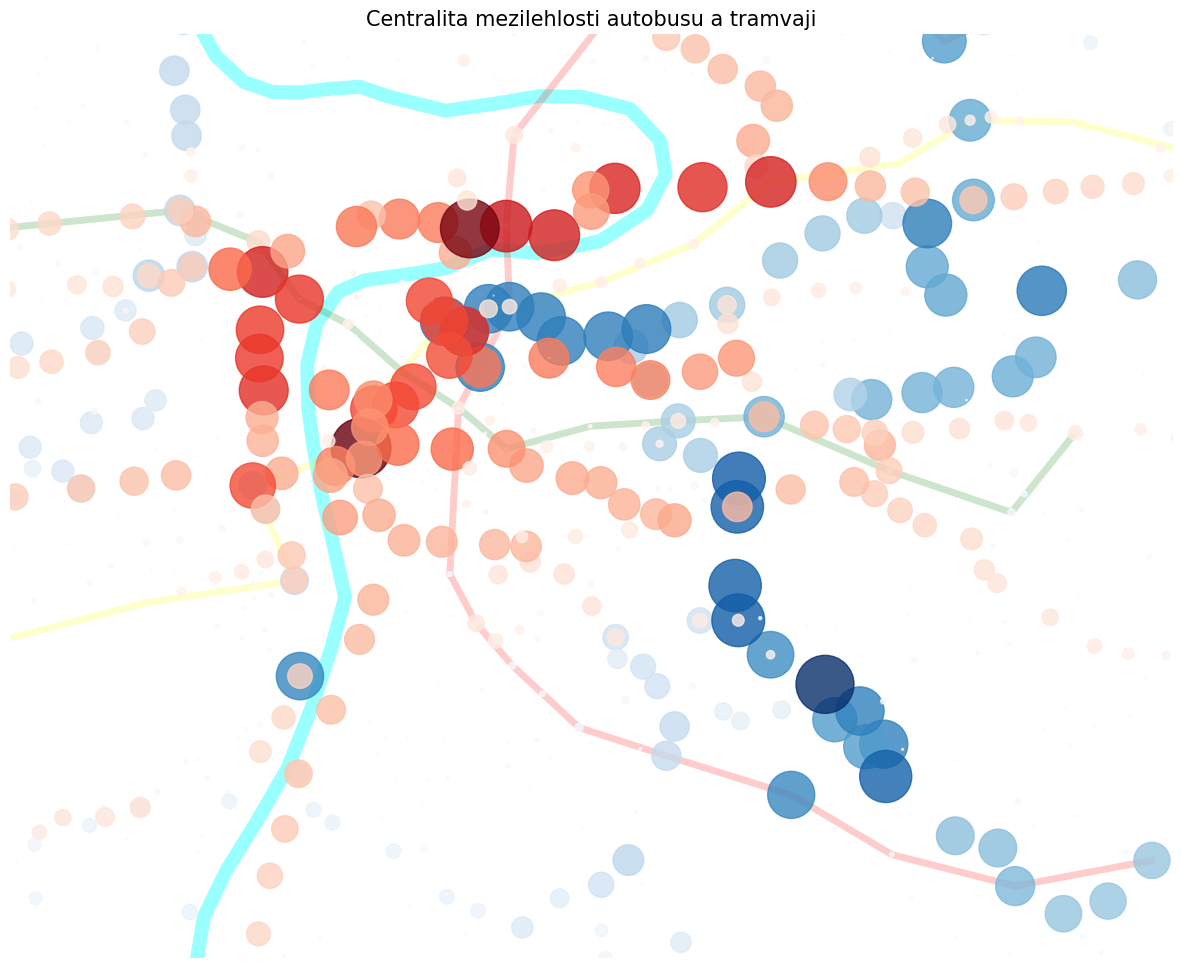

In [108]:
fig, ax = plt.subplots(figsize=(15, 12))

ax.plot(vltava_lons, vltava_lats, color='cyan', linewidth=10, alpha=0.4, label='Vltava')

ax.plot(stops_A['stop_lon'], stops_A['stop_lat'], color='green',  linewidth=5, alpha=0.2, label='Linka metra A')
ax.plot(stops_B['stop_lon'], stops_B['stop_lat'], color='yellow', linewidth=5, alpha=0.2, label='Linka metra B')
ax.plot(stops_C['stop_lon'], stops_C['stop_lat'], color='red',    linewidth=5, alpha=0.2, label='Linka metra C')

# autobusy
node_sizes  = [between_cent_norm.get(node, 0) * 5000 for node in G_bus.nodes()]
node_colors = [between_cent_norm.get(node, 0) for node in G_bus.nodes()]
nx.draw_networkx_nodes(G_bus, pos=pos_dict_bus, node_size=node_sizes, node_color=node_colors, cmap='Blues', alpha=0.8)

# tramavej
between_cent_norm_tram = nx.betweenness_centrality(G, weight='frequency', normalized=True)

node_sizes = [between_cent_norm_tram.get(node, 0) * 5000 for node in G.nodes()]
node_colors = [between_cent_norm_tram.get(node, 0) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos=pos_dict, node_size=node_sizes, node_color=node_colors, cmap='Reds', alpha=0.8)

ax.set_xlim([14.37, 14.53])
ax.set_ylim([50.02, 50.12])

plt.title('Centralita mezilehlosti autobusu a tramvaji', fontsize=15)
plt.axis('off')
plt.show()

Obrázek ukazuje, že tramvajová a autobusová doprava se ve své síti moc nepřekrývají. K překryvu dochází jenom v místech, která fungují jako přestupní uzly. Mimo tyto body se obě sítě chovají do značné míry nezávisle, přičemž se vzájemně doplňují.

Tramvaje mají vysokou koncentraci spojů v centrální části města, kde poskytují hustý a pravidelný provoz s vysokou kapacitu. Autobusy naopak obsluhují převážně okrajové a méně dostupné oblasti, kde tramvajová infrastruktura neexistuje nebo by nebyla efektivní. Díky tomu mohou mnohem lépe pokrýt velkou plochu a obsloužit místa s nižší intenzitou poptávky.

Celkově tedy platí, že tramvaje dominují v centru, zatímco autobusy rozšiřují dostupnost MHD mimo hlavní páteřní oblasti. Obě infrastruktury se tak vhodně doplňují a společně vytvářejí funkční a vyváženou síť MHD.